2025_04 - Deep Learning Project BioDS

#**Predicting Protein Subcellular Localisation**

**Objective**: To predict protein subcellular localisation from the input amino acid sequence using the ESM2-t6-8M embedder from Meta AI

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Step 0: Preparing the environment
!pip install transformers biopython
!pip install torch torchvision torchaudio
!pip install fair-esm
!pip install pandas scikit-learn
!pip install umap-learn numba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 70.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [5]:
# Step 0: Import necessary libraries
import pandas as pd
import numpy as np
import torch
import re
import esm
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from tqdm.notebook import tqdm
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, f1_score, roc_auc_score, classification_report,multilabel_confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score,roc_curve, auc
import umap
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

Loading the Dataset

In [6]:
# Step 1: Loading the dataset
#Loading the dataset

df = pd.read_csv('//content/drive/MyDrive/DL/modified_data.csv')

#Preview the dataset
print(df.index)
df.head()

RangeIndex(start=0, stop=6358, step=1)


,Name,Sequence,Nucleus,Cytoplasm,Secreted
0,MOTSC,MRWQEMGYIFYPRKLR,1,0,1
1,CD3CH,MTQRAGAAMLPSALLLLCVPGCLTVSGPSTVMGAVGESLSVQCRYE...,0,0,1
2,NBDY,MGDQPCASGRSTLPPGNAREAKPPKKRCLLAPRWDYPEGTPNGGST...,0,1,0
3,MED19,MENFTALFGAQADPPPPPTALGFGPGKPPPPPPPPAGGGPGTAPPP...,1,0,0
4,IGLC7,GQPKAAPSVTLFPPSSEELQANKATLVCLVSDFNPGAVTVAWKADG...,0,0,1


Embedding using ESM2-T6-8M

In [7]:
# Step 2: Preparing the embedder

# Loading the ESM model
model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# Prepare the data
sequences = df['Sequence'].tolist()
names = df['Name'].tolist()

# Parameters
batch_size = 8

all_embeddings = []

# Generate embeddings batch-wise
for i in tqdm(range(0, len(sequences), batch_size)):
    batch_labels = names[i:i+batch_size]
    batch_seqs = sequences[i:i+batch_size]
    batch_data = list(zip(batch_labels, batch_seqs))

    # Prepare batch
    batch_labels, batch_strs, batch_tokens = batch_converter(batch_data)
    batch_tokens = batch_tokens.to(device)

    # Pass through model
    with torch.no_grad():
        results = model(batch_tokens, repr_layers=[6])
        token_representations = results["representations"][6]

    # Mean Pooling
    for j, (_, seq) in enumerate(batch_data):
        seq_len = len(seq)
        embedding = token_representations[j, 1:seq_len+1].mean(0)
        all_embeddings.append(embedding.cpu().numpy())

# Convert embeddings list to array
all_embeddings = np.stack(all_embeddings)

# Save embeddings
np.save('esm_embeddings.npy', all_embeddings)

print("✅ Embedding generation complete. Saved as esm_embeddings.npy")

Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt


  0%|          | 0/795 [00:00<?, ?it/s]

✅ Embedding generation complete. Saved as esm_embeddings.npy


Labels array shape: (6358,)
Embeddings shape: (6358, 320)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette score: 0.3401331901550293


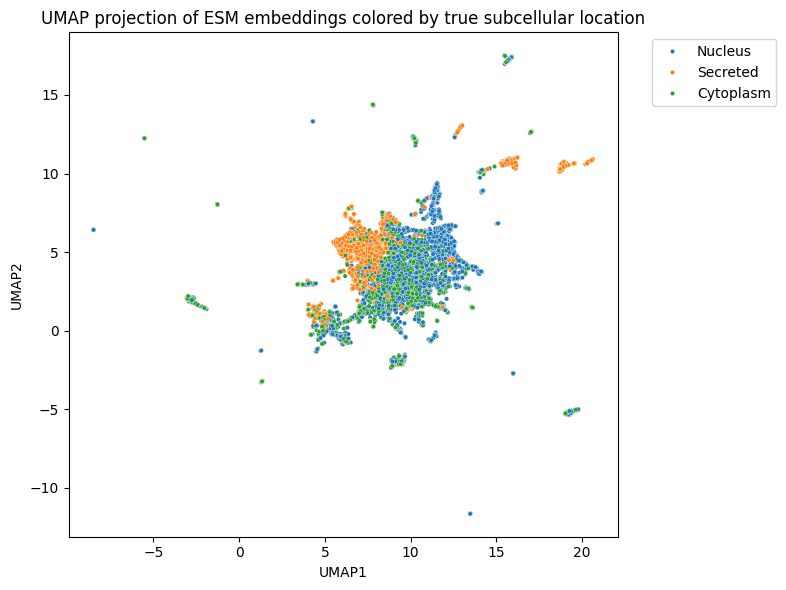

In [8]:
# Step 3: Visualising the embeddins using UMAP
# Define location columns
location_columns = ['Nucleus','Cytoplasm', 'Secreted']

# Assign labels based on location
def assign_label(row):
    for loc in location_columns:
        if row[loc] == 1:
            return loc
    return 'Unknown'

sample_labels = df.apply(assign_label, axis=1)
labels_array = sample_labels.to_numpy()
esm_embeddings = np.load("esm_embeddings.npy")

print(f"Labels array shape: {labels_array.shape}")
print(f"Embeddings shape: {esm_embeddings.shape}")

# UMAP reduction
reducer = umap.UMAP(random_state=42)
reduced = reducer.fit_transform(esm_embeddings)

# KMeans clustering
n_clusters = len(set(labels_array))
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(reduced)

# Map each cluster to its majority true label
cluster_to_label = {}
for i in range(n_clusters):
    cluster_indices = np.where(cluster_labels == i)[0]
    majority_label = Counter(labels_array[cluster_indices]).most_common(1)[0][0]
    cluster_to_label[i] = majority_label

# Relabel clusters with their majority label
mapped_labels = [cluster_to_label[cl] for cl in cluster_labels]

# Silhouette score
sil_score = silhouette_score(reduced, cluster_labels)
print(f"Silhouette score: {sil_score}")

# Plot with location-based legends
plt.figure(figsize=(8,6))
sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=labels_array, palette='tab10', s=10)
plt.title("UMAP projection of ESM embeddings colored by true subcellular location")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.tight_layout()
plt.show()


In [9]:
# Step 5: Defining the neural network

# Prepare target (subcellular localization labels)
labels = ['Nucleus', 'Cytoplasm', 'Secreted']

y = df[labels].values.astype(int)
X = np.load("esm_embeddings.npy")

print("Embedding shape:", X.shape)
print("Target shape:", y.shape)

# Dataset splitting
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size)

# Model
class ProteinClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train.shape[1]
output_dim = y_train.shape[1]
model = ProteinClassifier(input_dim, hidden_dim=256, output_dim=output_dim).to('cuda' if torch.cuda.is_available() else 'cpu')

Embedding shape: (6358, 320)
Target shape: (6358, 3)


In [10]:
# Step 6: Training the model

# Training setup
device = next(model.parameters()).device

label_freq = y_train.sum(axis=0)
n_samples = y_train.shape[0]

#Adding weights to account for class imbalance
pos_weights = (n_samples - label_freq) / label_freq
pos_weights = torch.tensor(pos_weights, dtype=torch.float32).to(device)

# Define loss function with pos_weight
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Early stopping params
best_val_loss = float('inf')
patience = 5
counter = 0
n_epochs = 50

# Training loop
for epoch in range(n_epochs):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_preds, val_targets = [], []
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()
            val_preds.append(preds.cpu().numpy())
            val_targets.append(yb.cpu().numpy())

    val_preds = np.vstack(val_preds)
    val_targets = np.vstack(val_targets)
    val_f1 = f1_score(val_targets, val_preds > 0.5, average='macro')
    val_auc = roc_auc_score(val_targets, val_preds, average='macro')

    print(f"Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f} | F1: {val_f1:.4f} | AUROC: {val_auc:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 1 | Train Loss: 0.7057 | Val Loss: 0.6842 | F1: 0.7751 | AUROC: 0.8866
Epoch 2 | Train Loss: 0.6789 | Val Loss: 0.6786 | F1: 0.7784 | AUROC: 0.8905
Epoch 3 | Train Loss: 0.6739 | Val Loss: 0.6759 | F1: 0.7978 | AUROC: 0.8934
Epoch 4 | Train Loss: 0.6706 | Val Loss: 0.6747 | F1: 0.8018 | AUROC: 0.8954
Epoch 5 | Train Loss: 0.6675 | Val Loss: 0.6721 | F1: 0.8107 | AUROC: 0.8958
Epoch 6 | Train Loss: 0.6674 | Val Loss: 0.6732 | F1: 0.7963 | AUROC: 0.8924
Epoch 7 | Train Loss: 0.6649 | Val Loss: 0.6719 | F1: 0.7993 | AUROC: 0.8962
Epoch 8 | Train Loss: 0.6632 | Val Loss: 0.6712 | F1: 0.8014 | AUROC: 0.8935
Epoch 9 | Train Loss: 0.6611 | Val Loss: 0.6717 | F1: 0.8065 | AUROC: 0.8966
Epoch 10 | Train Loss: 0.6618 | Val Loss: 0.6718 | F1: 0.8113 | AUROC: 0.8966
Epoch 11 | Train Loss: 0.6596 | Val Loss: 0.6704 | F1: 0.8121 | AUROC: 0.8982
Epoch 12 | Train Loss: 0.6584 | Val Loss: 0.6717 | F1: 0.8164 | AUROC: 0.8952
Epoch 13 | Train Loss: 0.6579 | Val Loss: 0.6721 | F1: 0.8103 | AUROC: 0.

In [11]:
# Step 7 : Classification Report for the model

# Generating the report
model.load_state_dict(torch.load("best_model.pt"))
model.eval()
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

y_true = y_val_tensor.numpy()
y_proba = X_val_tensor.detach().numpy()

with torch.no_grad():
    y_pred = model(X_val_tensor).numpy()
    y_pred_binary = (y_pred > 0.5).astype(int)

print(classification_report(y_val, y_pred_binary, target_names=labels))

              precision    recall  f1-score   support

     Nucleus       0.81      0.70      0.75       599
   Cytoplasm       0.83      0.74      0.79       669
    Secreted       0.89      0.94      0.91       319

   micro avg       0.84      0.77      0.80      1587
   macro avg       0.85      0.79      0.82      1587
weighted avg       0.84      0.77      0.80      1587
 samples avg       0.85      0.81      0.80      1587



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


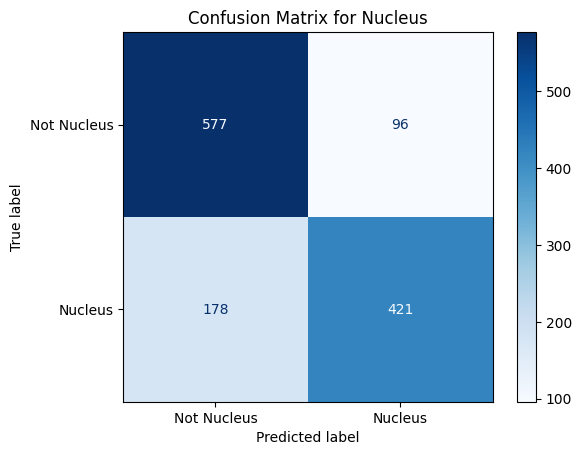

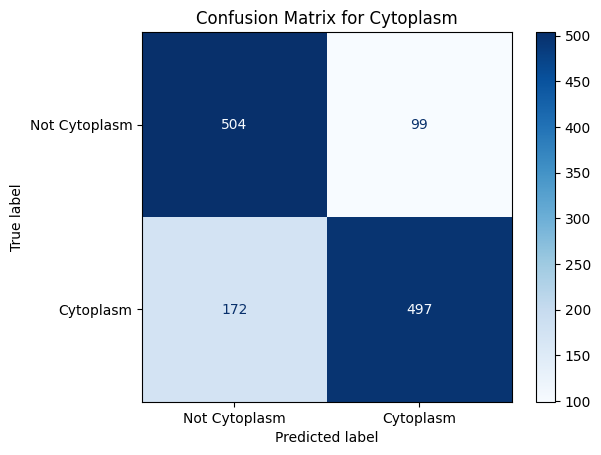

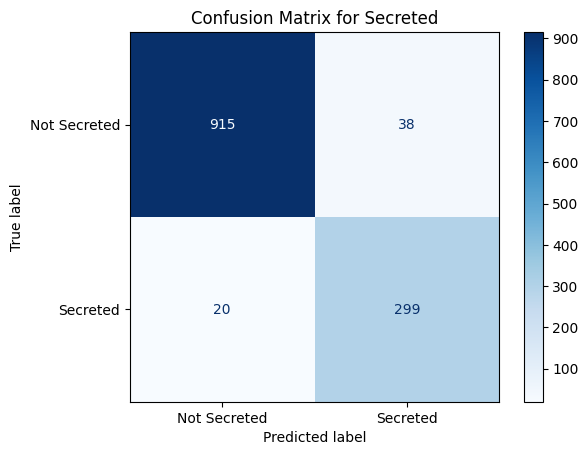

In [12]:
# Step 8: Confusion Matrices for each class
conf_matrices = multilabel_confusion_matrix(y_val, y_pred_binary)

for i, label in enumerate(labels):
    disp = ConfusionMatrixDisplay(conf_matrices[i], display_labels=[f'Not {label}', label])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix for {label}')
    plt.show()

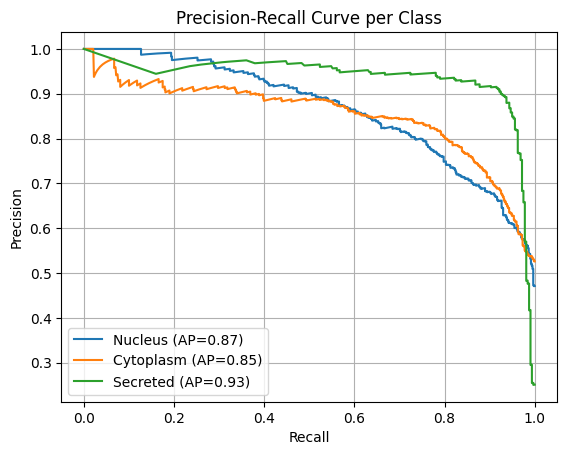

In [13]:
# Step 9: Generating the precision-recall curve per class

for i, label in enumerate(labels):
    precision, recall, _ = precision_recall_curve(y_val[:, i], y_pred[:, i])
    ap = average_precision_score(y_val[:, i], y_pred[:, i])
    plt.plot(recall, precision, label=f'{label} (AP={ap:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve per Class")
plt.legend()
plt.grid(True)
plt.show()


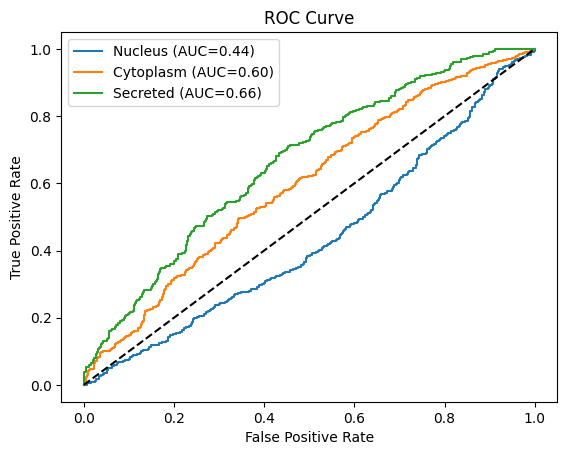

In [14]:
# Step 10: Generating the ROC curve for each class

for i, label in enumerate(labels):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()